In [7]:
# ==============================================================================
# OLIST MARKETPLACE CLIENT: EXPLORATORY DATA ANALYSIS (EDA)
# Phase 2: Logistics Impact on Customer Experience & Review Scores
# Language: Python 3 | Connection: PostgreSQL Direct Integration
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Configure corporate charting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Database Connection Configuration
# Replace 'postgres', 'password', 'localhost', '5432', and 'database_name' with your credentials
DB_USER = "postgres"
DB_PASSWORD = "h0mer0"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "postgres"

# Create the SQLAlchemy engine connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

print("🚀 Environment ready. Database engine configured successfully!")

🚀 Environment ready. Database engine configured successfully!


In [8]:
# Extract target tables directly from PostgreSQL via SQL queries
try:
    # Query only the required columns to save memory and optimize performance
    orders_query = """
        SELECT order_id, order_status, order_purchase_timestamp, 
               order_delivered_customer_date, order_estimated_delivery_date 
        FROM olis_orders;
    """
    reviews_query = """
        SELECT order_id, review_score 
        FROM olis_order_reviews;
    """
    
    orders_df = pd.read_sql(orders_query, con=engine)
    reviews_df = pd.read_sql(reviews_query, con=engine)
    
    print(f"📈 Successfully extracted {len(orders_df)} orders and {len(reviews_df)} reviews from PostgreSQL.")
except Exception as e:
    print(f"❌ Database connection or extraction failed: {e}")

# Data Cleansing: Drop rows where critical tracking data is missing
orders_df = orders_df.dropna(subset=['order_delivered_customer_date'])
reviews_df = reviews_df.dropna(subset=['review_score'])

# Parse strings into true datetime objects (pd.read_sql handles this, but forcing guarantees safety)
datetime_features = [
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for feature in datetime_features:
    orders_df[feature] = pd.to_datetime(orders_df[feature])

# Filter exclusively for completed 'delivered' orders to prevent metric distortion
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()

# Feature Engineering: Calculate real-world logistical performance timelines
# 1. Total Transit Time (Days from purchase click to doorstep)
delivered_orders['delivery_time_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.days

# 2. SLA Performance (Positive = Late / SLA Breach, Negative = Ahead of Schedule)
delivered_orders['sla_delta_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']
).dt.days

# 3. Binary Classification (1 if late, 0 if on time/early)
delivered_orders['is_delayed'] = np.where(delivered_orders['sla_delta_days'] > 0, 1, 0)

# Merge datasets using an inner join on the unique order key
df_analysis = pd.merge(
    delivered_orders[['order_id', 'delivery_time_days', 'sla_delta_days', 'is_delayed']],
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print(f"📋 Processed rows available for statistical modeling: {df_analysis.shape[0]}")

📈 Successfully extracted 99441 orders and 70000 reviews from PostgreSQL.
📋 Processed rows available for statistical modeling: 68011


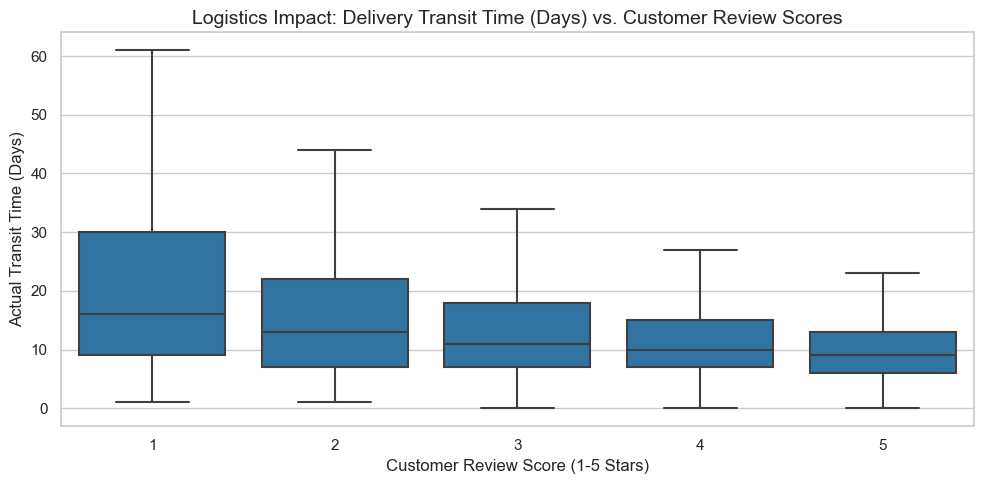

In [9]:
# Plot 1: Delivery Transit Time vs. Customer Review Scores
plt.figure(figsize=(10, 5))

# Boxplot utilizing a clean corporate blue tone
sns.boxplot(
    x='review_score', 
    y='delivery_time_days', 
    data=df_analysis, 
    color='#1f77b4',
    showfliers=False  # Hides extreme statistical outliers for presentation clarity
)

plt.title('Logistics Impact: Delivery Transit Time (Days) vs. Customer Review Scores')
plt.xlabel('Customer Review Score (1-5 Stars)')
plt.ylabel('Actual Transit Time (Days)')
plt.tight_layout()
plt.show()

In [10]:
# Calculate core KPIs for the GitHub portfolio summary
global_delay_rate = df_analysis['is_delayed'].mean() * 100
correlation_matrix = df_analysis[['delivery_time_days', 'sla_delta_days', 'review_score']].corr()

print("==============================================================================")
print("                           EXECUTIVE LOGISTICS SUMMARY                        ")
print("==============================================================================")
print(f"💡 Marketplace Overdue Delivery Rate (SLA Breach): {global_delay_rate:.2f}%")
print("\n📋 Pearson Correlation Coefficient Matrix:")
print(correlation_matrix)
print("==============================================================================")

                           EXECUTIVE LOGISTICS SUMMARY                        
💡 Marketplace Overdue Delivery Rate (SLA Breach): 6.64%

📋 Pearson Correlation Coefficient Matrix:
                    delivery_time_days  sla_delta_days  review_score
delivery_time_days            1.000000        0.604317     -0.332384
sla_delta_days                0.604317        1.000000     -0.263012
review_score                 -0.332384       -0.263012      1.000000
